In [132]:
%run Packages_and_Functions.ipynb


In [2]:
from collections import Counter
import seaborn as sns


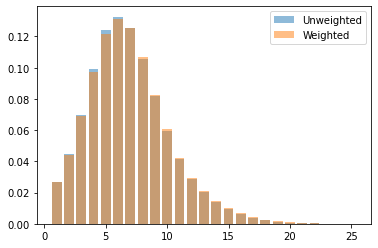

In [11]:
## How to plot a histogram

plt.bar(HIST[0].keys(),np.array(list(HIST[0].values())),label="Unweighted",alpha=.5)
plt.bar(HIST_w[0].keys(),np.array(list(HIST_w[0].values())),label="Weighted",alpha=.5)
plt.legend()
plt.show()

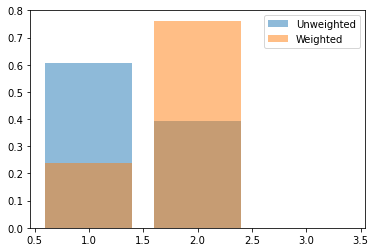

In [13]:
plt.bar(HIST[-1].keys(),np.array(list(HIST[-1].values())),label="Unweighted",alpha=.5)
plt.bar(HIST_w[-1].keys(),np.array(list(HIST_w[-1].values())),label="Weighted",alpha=.5)
plt.legend()
plt.show()

In [147]:
itern = 30 # number of repetitions per value of p
interval= 15 #how many values of p to consider
N = 150 # Number of vertices
P_temp = list(np.linspace(0.1,0.9,interval))
P = P_temp[::-1]


## Keep the empirical distributions
HIST = [{} for i in range(interval)]
HIST_w = [{} for i in range(interval)]

## Keep the TV distances
TV_dist = np.zeros(interval) 
TV_dist_STD = np.zeros(interval)
TV_dist_quantile_75 = np.zeros(interval)
TV_dist_quantile_25 = np.zeros(interval)

## Keep the average distance (unweighted)
Means = np.zeros(interval) 
Means_STD = np.zeros(interval)

## Keep the average distance (weighted)
Means_w = np.zeros(interval) 
Means_w_STD = np.zeros(interval)

for i,e in enumerate(P): # e is for exponent
    print(e) ## Keep track of where we are

    p = lambda n: 1/np.power(n,e)
    
    # Keep the current list of instances generated and computed, length would be itern
    TV_dist_list = np.zeros(itern)
    Mean_List = np.zeros(itern)
    Mean_w_List = np.zeros(itern)
    
    # Start generating instances
    for t in range(itern):
        
        G = random_geometric_weighted_graph(N,p(N))
        Hist = {} #current histograms of TV distances
        Hist_w = {}

        Dw = G.shortest_path_all_pairs(by_weight=True)[0]
        D = G.shortest_path_all_pairs()[0]
        for v in G.vertices(sort=1):
            temp_dict_w = Counter(Dw[v].values()) # dict of dist -> how many times it occures
            for k in temp_dict_w:
                if k not in Hist_w:
                    Hist_w[k] = temp_dict_w[k]
                else:
                    Hist_w[k] += temp_dict_w[k]
            temp_dict = Counter(D[v].values())
            for k in temp_dict:
                if k not in Hist:
                    Hist[k] = temp_dict[k]
                else:
                    Hist[k] += temp_dict[k]
                    
        
        Hist_w.pop(0) #get rid of counter of 0 distances
        Hist.pop(0)
        
        ## Update the empirical distributions
        
        C1 = Counter(HIST[i])
        C2 = Counter(Hist)
        HIST[i] = dict(C1+C2)
        
        C1_w = Counter(HIST_w[i])
        C2_w = Counter(Hist_w)
        HIST_w[i] = dict(C1_w+C2_w)
        ## Calculate the weighted mean of distances, before we normalize
        Mean_List[t] += np.sum([i*Hist[i] for i in Hist])/sum(Hist.values())
        Mean_w_List[t] += np.sum([i*Hist_w[i] for i in Hist_w])/sum(Hist_w.values())
        
        ## Normalize
        Sw = sum(Hist_w.values())
        for k in Hist_w:
            Hist_w[k]/= Sw

        S = sum(Hist.values())
        for k in Hist:
            Hist[k]/= S
        
        ## Calculate the empirical TV distance between the two current histograms
        TV = [np.abs(Hist_w.setdefault(i,0) - Hist.setdefault(i,0)) for i in range(max(len(Hist),len(Hist_w))+1)]
#         print(V)
        TV_dist_list[t] += sum(TV)
    
    #normalize the histograms saved
    TOT = sum(HIST[i].values())
    for k in HIST[i]:
        HIST[i][k]/= TOT
    
    TOT_w = sum(HIST_w[i].values())
    for k in HIST_w[i]:
        HIST_w[i][k]/= TOT_w
    
    Means[i] = sum(Mean_List)/itern
    Means_STD[i] = np.std(Mean_List)
    Means_w[i] = sum(Mean_w_List)/itern
    Means_w_STD[i] = np.std(Mean_w_List)
    
    TV_dist[i] = sum(TV_dist_list)/itern
    TV_dist_STD[i] = np.std(TV_dist_list)
    TV_dist_quantile_75[i]= np.quantile(TV_dist_list,.75)
    TV_dist_quantile_25[i]= np.quantile(TV_dist_list,.25)

# Process the HIST to array for heatmap:
M = max([len(HIST[i]) for i in range(interval)])
H_Heatmap = [dict_hist_to_array(HIST[i], M) for i in range(len(HIST))]
arr_H = np.array(H_Heatmap)
M_w = max([len(HIST_w[i]) for i in range(interval)])
H_Heatmap_w = [dict_hist_to_array(HIST_w[i], M_w) for i in range(len(HIST_w))]
arr_H_w = np.array(H_Heatmap_w)

0.9
0.8428571428571429
0.7857142857142857
0.7285714285714286
0.6714285714285715
0.6142857142857143
0.5571428571428572
0.5
0.44285714285714284
0.3857142857142858
0.3285714285714286
0.27142857142857146
0.2142857142857143
0.15714285714285714
0.1


Text(0.5, 1.0, '$TV$-distance between $d_\\Gamma$ and $d_G$')

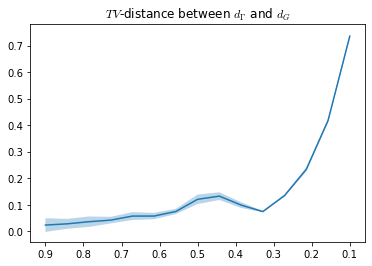

In [148]:
xticks = np.arange(0.1,1.1,0.1)[::-1]
fig, ax = plt.subplots()
ax.set_xticklabels([f"{label:.1f}" for label in xticks])
xrange = P[::-1]
ax.plot(xrange,TV_dist,label = "TV distance")
ax.fill_between(xrange,TV_dist+TV_dist_STD,TV_dist-TV_dist_STD,alpha=.3)
ax.set_title("$TV$-distance between $d_\Gamma$ and $d_G$")
# ax.fill_between(xrange,TV_dist_quantile_75,TV_dist_quantile_25,alpha=.3)

[10.135302035047447, 6.418159837312079, 4.695921338302405, 3.702420015270126, 3.0558941017376, 2.6015967252860803, 2.264891854846345, 2.0053541274546562, 1.7991827782844783, 1.6314524289290744, 1.4923288031747715, 1.3750685514244556, 1.2748933644594338, 1.188322801357357, 1.112761655756681]


Text(0.5, 1.0, 'The mean distance in $\\Gamma(n,p)$ and the underlying $G$')

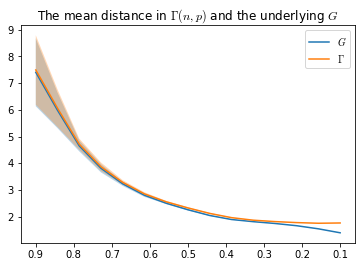

In [149]:
fig, ax = plt.subplots()

LOG = [np.log(N)/(np.log((N-1)*np.power(N,-e) )) for e in P ]
print(LOG)
ax.set_xticklabels([f"{label:.1f}" for label in xticks])
ax.plot(xrange,Means,label = "$G$")
ax.fill_between(xrange,Means+Means_STD,Means-Means_STD,alpha=.3)
ax.plot(xrange,Means_w,label = "$\Gamma$")
ax.fill_between(xrange,Means_w + Means_w_STD,Means_w - Means_w_STD,alpha=.3)
# ax.plot(xrange,LOG)
ax.legend()
ax.set_title("The mean distance in $\Gamma(n,p)$ and the underlying $G$")
# ax.show()


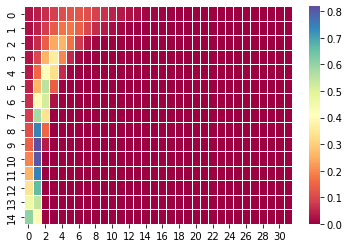

In [150]:
# arr_H[arr_H] = 0
# print(arr_H)
# sns.color_palette(, as_cmap=True)
ax = sns.heatmap(arr_H, linewidth=0.5,cmap="Spectral")
plt.show()

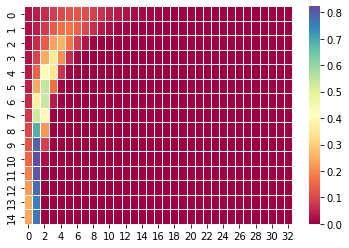

In [151]:
# print(H_Heatmap_w)
ax = sns.heatmap(arr_H_w, linewidth=0.5,cmap="Spectral")
plt.show()

In [152]:
ax = sns.heatmap(arr_H_w-arr_H, linewidth=0.5,cmap="Spectral")
plt.show()

ValueError: operands could not be broadcast together with shapes (15,33) (15,32) 

In [383]:
arr_H = np.array(H_Heatmap)
arr_H_w = np.array(H_Heatmap_w)
arr_H_w.shape

(15, 10)

In [414]:
ax = sns.heatmap(arr_H_w-arr_H, linewidth=0.5)
plt.show()

ValueError: operands could not be broadcast together with shapes (3,10) (3,9) 

In [350]:
itern = 3 # number of repetitions per value of p
interval= 3 #how many values of p to consider
N = 50 # Number of vertices
P_temp = list(np.linspace(0.1,0.9,interval))
P = P_temp[::-1]
## Keep the empirical distributions
HIST = [{} for i in range(interval)]
HIST_w = [{} for i in range(interval)]
TV_dist = np.zeros(interval) # Keep the TV distances
TV_dist_STD = np.zeros(interval)
TV_dist_quantile_75 = np.zeros(interval)
TV_dist_quantile_25 = np.zeros(interval)

Means = np.zeros(interval) # Keep the average distance (unweighted)
Means_STD = np.zeros(interval)

Means_w = np.zeros(interval) # Keep the average distance (weighted)
Means_w_STD = np.zeros(interval)

for i,e in enumerate(P): # e is for exponent
    print(e) ## Keep track of where we are

    p = lambda n: 1/np.power(n,e)
    
    # Keep the current list of instances generated and computed, length would be itern
    TV_dist_list = np.zeros(itern)
    Mean_List = np.zeros(itern)
    Mean_w_List = np.zeros(itern)
    
    # Start generating instances
    for t in range(itern):
        
        G = random_geometric_weighted_graph(N,p(N))
        Hist = {} #current histograms of TV distances
        Hist_w = {}

        Dw = G.shortest_path_all_pairs(by_weight=True)[0]
        D = G.shortest_path_all_pairs()[0]
        for v in G.vertices(sort=1):
            temp_dict_w = Counter(Dw[v].values()) # dict of dist -> how many times it occures
            for k in temp_dict_w:
                if k not in Hist_w:
                    Hist_w[k] = temp_dict_w[k]
                else:
                    Hist_w[k] += temp_dict_w[k]
            temp_dict = Counter(D[v].values())
            for k in temp_dict:
                if k not in Hist:
                    Hist[k] = temp_dict[k]
                else:
                    Hist[k] += temp_dict[k]
                    
        
        Hist_w.pop(0) #get rid of counter of 0 distances
        Hist.pop(0)
        
        ## Update the empirical distributions
        
        C1 = Counter(HIST[i])
        C2 = Counter(Hist)
        HIST[i] = dict(C1+C2)
        
        C1_w = Counter(HIST_w[i])
        C2_w = Counter(Hist_w)
        HIST_w[i] = dict(C1_w+C2_w)
        ## Calculate the weighted mean of distances, before we normalize
        Mean_List[t] += np.sum([i*Hist[i] for i in Hist])/sum(Hist.values())
        Mean_w_List[t] += np.sum([i*Hist_w[i] for i in Hist_w])/sum(Hist_w.values())
        
        ## Normalize
        Sw = sum(Hist_w.values())
        for k in Hist_w:
            Hist_w[k]/= Sw

        S = sum(Hist.values())
        for k in Hist:
            Hist[k]/= S
        
        ## Calculate the empirical TV distance between the two current histograms
        TV = [np.abs(Hist_w.setdefault(i,0) - Hist.setdefault(i,0)) for i in range(max(len(Hist),len(Hist_w))+1)]
#         print(V)
        TV_dist_list[t] += sum(TV)
    
    #normalize the histograms saved
    TOT = sum(HIST[i].values())
    for k in HIST[i]:
        HIST[i][k]/= TOT
    
    TOT_w = sum(HIST_w[i].values())
    for k in HIST_w[i]:
        HIST_w[i][k]/= TOT_w
    
    Means[i] = sum(Mean_List)/itern
    Means_STD[i] = np.std(Mean_List)
    Means_w[i] = sum(Mean_w_List)/itern
    Means_w_STD[i] = np.std(M
                            ean_w_List)
    
    TV_dist[i] = sum(TV_dist_list)/itern
    TV_dist_STD[i] = np.std(TV_dist_list)
    TV_dist_quantile_75[i]= np.quantile(TV_dist_list,.75)
    TV_dist_quantile_25[i]= np.quantile(TV_dist_list,.25)
    
# Process the HIST to array for heatmap:
M = max([len(HIST[i]) for i in range(interval)])
H_Heatmap = [dict_hist_to_array(HIST[i], M) for i in range(len(HIST))]
M_w = max([len(HIST_w[i]) for i in range(interval)])
H_Heatmap_w = [dict_hist_to_array(HIST_w[i], M_w) for i in range(len(HIST_w))]

0.9
0.5
0.1


15

In [146]:
def dict_hist_to_array(dict_hist, dim,thresh = 0):
    u = np.zeros(dim)
    for k,v in dict_hist.items():
#         print(k)
        u[k-1] = v
    uthresh = np.array(u[u>=thresh])
    return np.pad(uthresh, (0, dim - len(uthresh)), 'constant')

In [198]:
N = [100,1000]
n = 100
AVG = 50
Alpha = [0.1,0.2,0.3,0.4,0.5,0.6,.7,.8,.9]
Lower1 = list()
Lower2 = list()
for alpha in Alpha:
    avg = 0
    for i in range(AVG):
        
        p = lambda x: np.power(x,-alpha)
        avg +=max(np.random.geometric(1-p(n),int(n*(n-1)*0.5)))/AVG
#     Lower.append(max(np.random.geometric(1-p(n),int(n*(n-1)*0.5))))
    Lower1.append(avg)
n=1000
for alpha in Alpha:
    avg = 0
    for i in range(AVG):
        
        p = lambda x: np.power(x,-alpha)
        avg +=max(np.random.geometric(1-p(n),int(n*(n-1)*0.5)))/AVG
#     Lower.append(max(np.random.geometric(1-p(n),int(n*(n-1)*0.5))))
    Lower2.append(avg)
# K = 
# L = [max(np.random.geometric(1-p(n),int(n*(n-1)*0.5))) for  in N]

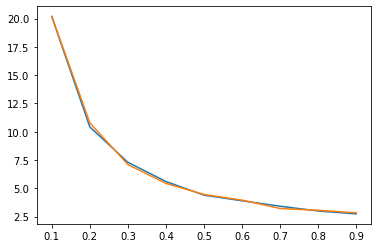

In [200]:
plt.plot(Alpha,Lower1,label="100")
plt.plot(Alpha,Lower2,label="1000")
# plt.plot(Alpha, [1 + 2/alpha for alpha in Alpha])
# plt.plot(Alpha, [1+ 2/alpha for alpha in Alpha])
# plt.plot(Alpha, [2/alpha for alpha in Alpha])

In [193]:
# M = max([len(HIST[i]) for i in range(interval)])
# H_Heatmap = [dict_hist_to_array(HIST[i], M) for i in range(len(HIST))]
# arr_H = np.array(H_Heatmap)
# M_w = max([len(HIST_w[i]) for i in range(interval)])
# H_Heatmap_w = [dict_hist_to_array(HIST_w[i], M_w) for i in range(len(HIST_w))]
# arr_H_w = np.array(H_Heatmap_w)


In [194]:
N = [500]
n = 1000
AVG = 50
Alpha = [0.1,0.2,0.3,0.4,0.5,0.6,.7,.8,.9]
Lower = list()
for alpha in Alpha:
    avg = 0
    for i in range(AVG):
        
        p = lambda x: np.power(x,-alpha)
        avg +=max(np.random.geometric(1-p(n),int(n*(n-1)*0.5)))/AVG
#     Lower.append(max(np.random.geometric(1-p(n),int(n*(n-1)*0.5))))
    Lower.append(avg)
# K = 
# L = [max(np.random.geometric(1-p(n),int(n*(n-1)*0.5))) for  in N]

In [ ]:
plt.plot(Alpha,Lower)
# plt.plot(Alpha, [1 + 2/alpha for alpha in Alpha])
plt.plot(Alpha, [1+ 2/alpha for alpha in Alpha])
plt.plot(Alpha, [2/alpha for alpha in Alpha])